# Полный анализ проекта «Помощник выбора на полке»

1. Разведка данных (EDA)
2. Профиль пользователя и скоринг
3. Бейзлайны и метрики
4. Анализ ошибок и ограничений

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

ROOT = Path.cwd().parent
DATA = Path(os.environ.get('DATA_PERFUME_DIR', ROOT / 'data'))
sys.path.insert(0, str(ROOT / 'backend'))

def load(name):
    for ext in ('.parquet', '.csv'):
        p = DATA / f'{name}{ext}'
        if p.exists():
            return pd.read_parquet(p) if ext == '.parquet' else pd.read_csv(p)
    return None

---
# Часть 1. Разведка данных (EDA)

## 1.1 Каталог ароматов

In [2]:
perfumes = load('perfumes').drop_duplicates(subset=['perfume_id'], keep='first')
perfume_notes = load('perfume_notes')

print(f'perfumes: {perfumes.shape}')
print(f'perfume_notes: {perfume_notes.shape}')
print(f'\nУникальных SKU: {perfumes["perfume_id"].nunique()}')
print(f'Уникальных нот: {perfume_notes["note"].nunique()}')
print(f'\nКолонки perfumes: {list(perfumes.columns)}')
print(f'Колонки perfume_notes: {list(perfume_notes.columns)}')
print(f'\nПропуски в perfumes:')
print(perfumes.isnull().sum()[perfumes.isnull().sum() > 0])

perfumes: (4521, 29)
perfume_notes: (39693, 4)

Уникальных SKU: 4521
Уникальных нот: 827

Колонки perfumes: ['parf_id', 'perfume_id', 'brand', 'name', 'clslove', 'clslike', 'clsdislike', 'clswinter', 'clsspring', 'clssummer', 'clsautumn', 'clsday', 'clsnight', 'i_have_it', 'i_had_it', 'i_want_it', 'allVotes', 'longs1', 'longs2', 'longs3', 'longs4', 'longs5', 'sil1', 'sil2', 'sil3', 'sil4', 'upd', 'url', 'status']
Колонки perfume_notes: ['perfume_id', 'note', 'votes', 'upd']

Пропуски в perfumes:
Series([], dtype: int64)


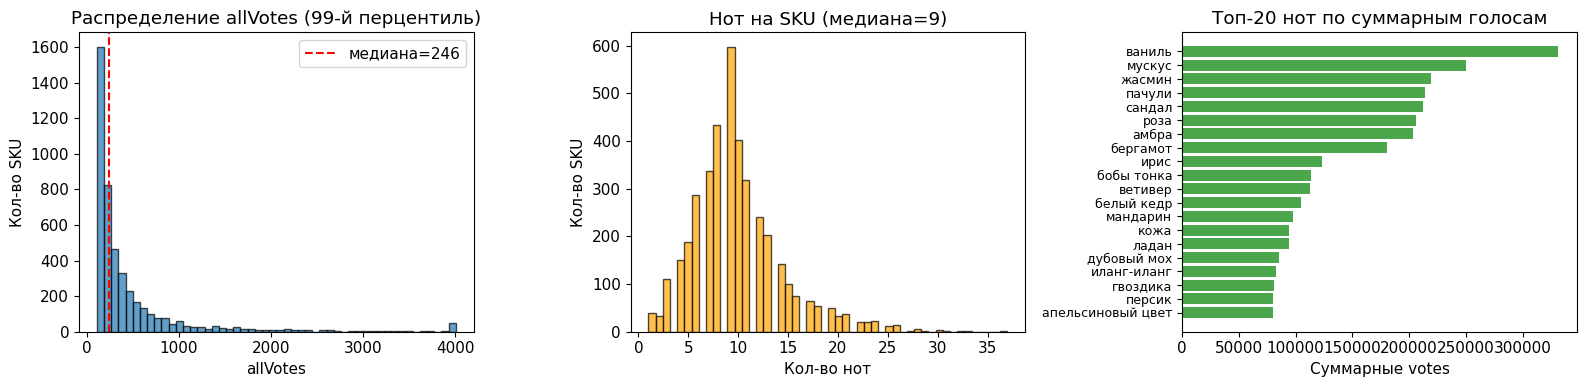


Нот на SKU: min=1, max=37, mean=9.9
Votes на запись: min=0, max=5968, mean=188.4


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

if 'allVotes' in perfumes.columns:
    v = perfumes['allVotes'].clip(upper=perfumes['allVotes'].quantile(0.99))
    axes[0].hist(v, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_title('Распределение allVotes (99-й перцентиль)')
    axes[0].set_xlabel('allVotes')
    axes[0].set_ylabel('Кол-во SKU')
    axes[0].axvline(v.median(), color='red', ls='--', label=f'медиана={v.median():.0f}')
    axes[0].legend()

notes_per_sku = perfume_notes.groupby('perfume_id').size()
axes[1].hist(notes_per_sku, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title(f'Нот на SKU (медиана={notes_per_sku.median():.0f})')
axes[1].set_xlabel('Кол-во нот')
axes[1].set_ylabel('Кол-во SKU')

votes_per_note = perfume_notes.groupby('note')['votes'].sum().sort_values(ascending=False)
top20 = votes_per_note.head(20)
axes[2].barh(range(len(top20)), top20.values, color='green', alpha=0.7)
axes[2].set_yticks(range(len(top20)))
axes[2].set_yticklabels(top20.index, fontsize=9)
axes[2].invert_yaxis()
axes[2].set_title('Топ-20 нот по суммарным голосам')
axes[2].set_xlabel('Суммарные votes')

plt.tight_layout()
plt.show()

print(f'\nНот на SKU: min={notes_per_sku.min()}, max={notes_per_sku.max()}, mean={notes_per_sku.mean():.1f}')
print(f'Votes на запись: min={perfume_notes["votes"].min()}, max={perfume_notes["votes"].max()}, mean={perfume_notes["votes"].mean():.1f}')

## 1.2 Данные органа

In [4]:
sessions = load('organ_sessions')
components = load('organ_recipe_components')
aroma_map = load('organ_aroma_notes_map')
presses = load('organ_presses')
aromas = load('organ_aromas')
feedback = load('organ_feedback')

print(f'sessions: {sessions.shape}')
print(f'components: {components.shape}')
print(f'aroma_map: {aroma_map.shape}')
print(f'presses: {presses.shape if presses is not None else None}')
print(f'aromas: {aromas.shape if aromas is not None else None}')
print(f'feedback: {feedback.shape if feedback is not None else None}')
print(f'\nКолонки sessions: {list(sessions.columns)}')
print(f'Колонки aroma_map: {list(aroma_map.columns)}')

sessions: (1000, 7)
components: (6000, 4)
aroma_map: (12, 3)
presses: (20119, 6)
aromas: (12, 3)
feedback: (1000, 4)

Колонки sessions: ['session_id', 'user_id', 'preset_id', 'channels_count', 'started_ms', 'ended_ms', 'target_perfume_id']
Колонки aroma_map: ['aroma_id', 'note', 'weight']


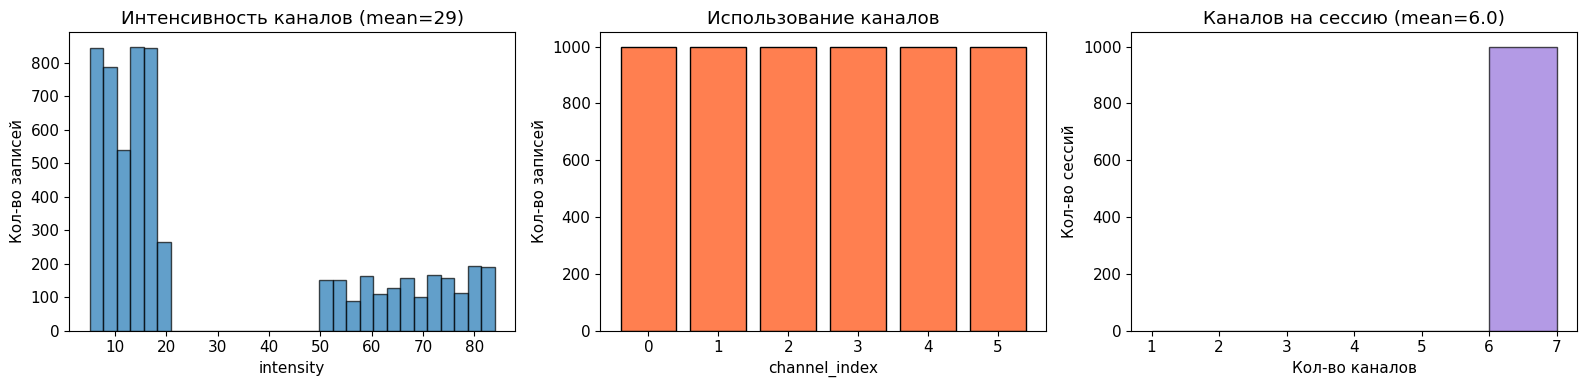

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(components['intensity'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Интенсивность каналов (mean={components["intensity"].mean():.0f})')
axes[0].set_xlabel('intensity')
axes[0].set_ylabel('Кол-во записей')

ch_counts = components.groupby('channel_index').size()
axes[1].bar(ch_counts.index, ch_counts.values, color='coral', edgecolor='black')
axes[1].set_title('Использование каналов')
axes[1].set_xlabel('channel_index')
axes[1].set_ylabel('Кол-во записей')

comps_per_sess = components.groupby('session_id').size()
axes[2].hist(comps_per_sess, bins=range(1, comps_per_sess.max() + 2), edgecolor='black', alpha=0.7, color='mediumpurple')
axes[2].set_title(f'Каналов на сессию (mean={comps_per_sess.mean():.1f})')
axes[2].set_xlabel('Кол-во каналов')
axes[2].set_ylabel('Кол-во сессий')

plt.tight_layout()
plt.show()

## 1.3 Маппинг орган → ноты → каталог

Нот в органе: 12
Нот в каталоге: 827
Пересечение: 12 (1.5% каталога)

Ноты органа: ['амбра', 'белый кедр', 'бергамот', 'ваниль', 'ветивер', 'жасмин', 'ирис', 'мандарин', 'мускус', 'пачули', 'роза', 'сандал']


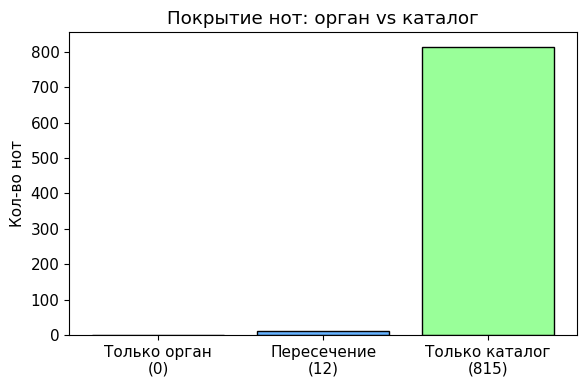

In [6]:
organ_notes = set(aroma_map['note'].str.strip().str.lower().unique())
catalog_notes = set(perfume_notes['note'].str.strip().str.lower().unique())

overlap = organ_notes & catalog_notes
only_organ = organ_notes - catalog_notes
only_catalog = catalog_notes - organ_notes

print(f'Нот в органе: {len(organ_notes)}')
print(f'Нот в каталоге: {len(catalog_notes)}')
print(f'Пересечение: {len(overlap)} ({100*len(overlap)/len(catalog_notes):.1f}% каталога)')
print(f'\nНоты органа: {sorted(organ_notes)}')
if only_organ:
    print(f'Только в органе (нет в каталоге): {sorted(only_organ)}')

fig, ax = plt.subplots(figsize=(6, 4))
sizes = [len(only_organ), len(overlap), len(only_catalog)]
labels = [f'Только орган\n({len(only_organ)})', f'Пересечение\n({len(overlap)})', f'Только каталог\n({len(only_catalog)})']
colors = ['#ff9999', '#66b3ff', '#99ff99']
ax.bar(labels, sizes, color=colors, edgecolor='black')
ax.set_title('Покрытие нот: орган vs каталог')
ax.set_ylabel('Кол-во нот')
plt.tight_layout()
plt.show()

## 1.4 Целевые ароматы (target)

Целевых SKU: 778 уникальных из 1000 сессий
В каталоге: 891 (89.1%)
Не в каталоге: 109


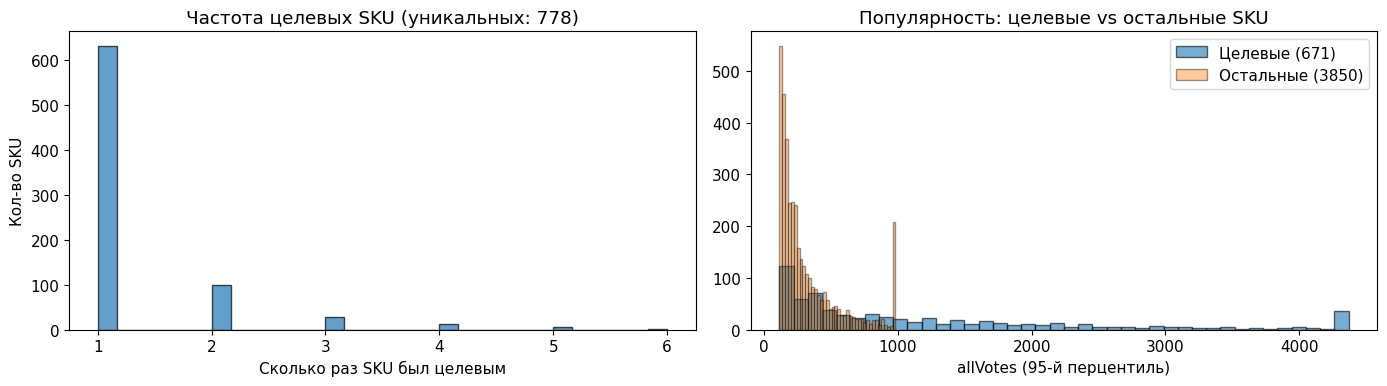

In [7]:
targets = sessions['target_perfume_id']
in_catalog = targets.isin(perfumes['perfume_id'])

print(f'Целевых SKU: {targets.nunique()} уникальных из {len(targets)} сессий')
print(f'В каталоге: {in_catalog.sum()} ({100*in_catalog.mean():.1f}%)')
print(f'Не в каталоге: {(~in_catalog).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

target_counts = targets.value_counts()
axes[0].hist(target_counts.values, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Частота целевых SKU (уникальных: {len(target_counts)})')
axes[0].set_xlabel('Сколько раз SKU был целевым')
axes[0].set_ylabel('Кол-во SKU')

if 'allVotes' in perfumes.columns:
    target_pop = perfumes[perfumes['perfume_id'].isin(targets)]['allVotes']
    non_target_pop = perfumes[~perfumes['perfume_id'].isin(targets)]['allVotes']
    axes[1].hist(target_pop.clip(upper=target_pop.quantile(0.95)), bins=40, alpha=0.6, label=f'Целевые ({len(target_pop)})', edgecolor='black')
    axes[1].hist(non_target_pop.clip(upper=non_target_pop.quantile(0.95)), bins=40, alpha=0.4, label=f'Остальные ({len(non_target_pop)})', edgecolor='black')
    axes[1].set_title('Популярность: целевые vs остальные SKU')
    axes[1].set_xlabel('allVotes (95-й перцентиль)')
    axes[1].legend()

plt.tight_layout()
plt.show()

## 1.5 Нажатия и корреляция каналов

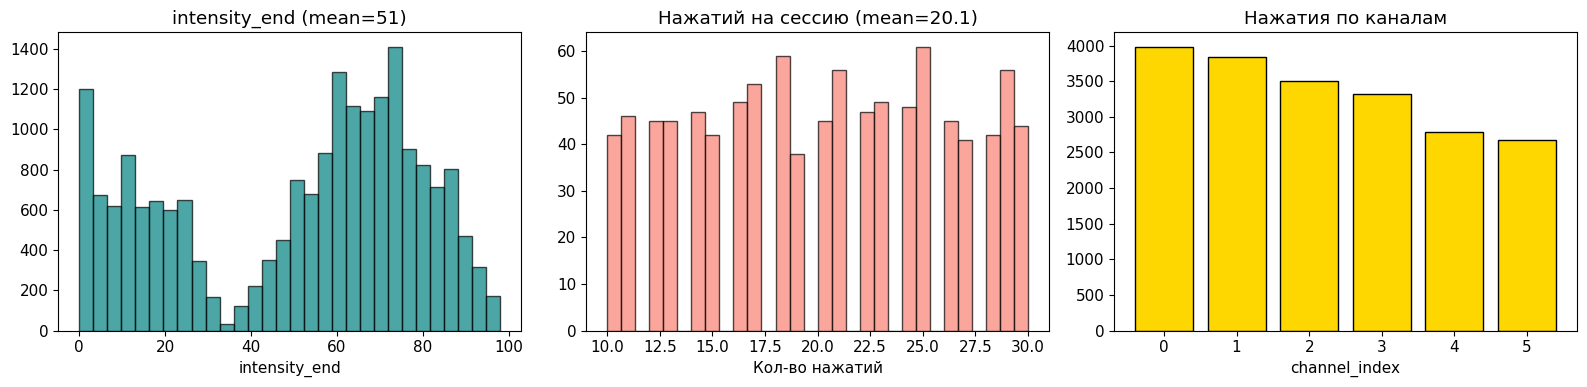

In [8]:
if presses is not None and len(presses) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].hist(presses['intensity_end'].clip(0, 100), bins=30, edgecolor='black', alpha=0.7, color='teal')
    axes[0].set_title(f'intensity_end (mean={presses["intensity_end"].mean():.0f})')
    axes[0].set_xlabel('intensity_end')
    presses_per_sess = presses.groupby('session_id').size()
    axes[1].hist(presses_per_sess, bins=30, edgecolor='black', alpha=0.7, color='salmon')
    axes[1].set_title(f'Нажатий на сессию (mean={presses_per_sess.mean():.1f})')
    axes[1].set_xlabel('Кол-во нажатий')
    ch_presses = presses.groupby('channel_index').size()
    axes[2].bar(ch_presses.index, ch_presses.values, color='gold', edgecolor='black')
    axes[2].set_title('Нажатия по каналам')
    axes[2].set_xlabel('channel_index')
    plt.tight_layout()
    plt.show()
else:
    print('presses отсутствуют')

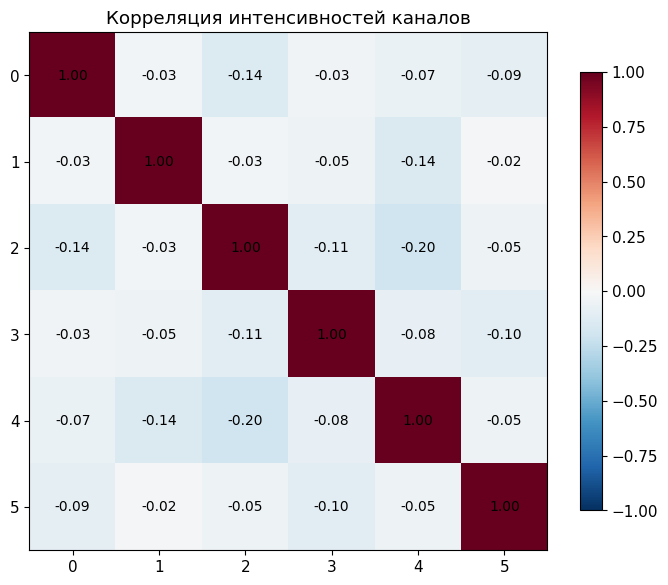

In [9]:
pivot = components.pivot_table(index='session_id', columns='channel_index', values='intensity', fill_value=0)
corr = pivot.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=10)
ax.set_title('Корреляция интенсивностей каналов')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 1.6 Сводка EDA

In [10]:
print('=== Ключевые выводы ===')
print(f'• Каталог: {perfumes["perfume_id"].nunique()} SKU, {len(catalog_notes)} нот')
print(f'• Орган: {len(sessions)} сессий, 6 каналов, {len(organ_notes)} нот')
print(f'• Покрытие нот: {len(overlap)}/{len(catalog_notes)} = {100*len(overlap)/len(catalog_notes):.1f}%')
print(f'• Целевых SKU в каталоге: {in_catalog.sum()}/{len(targets)} = {100*in_catalog.mean():.1f}%')
print(f'• Медиана нот на SKU: {notes_per_sku.median():.0f}')
if 'allVotes' in perfumes.columns:
    print(f'• Медиана allVotes: {perfumes["allVotes"].median():.0f}')
print(f'• Средняя интенсивность рецепта: {components["intensity"].mean():.0f}')
print(f'• Каналов на сессию: {comps_per_sess.mean():.1f}')

=== Ключевые выводы ===
• Каталог: 4521 SKU, 827 нот
• Орган: 1000 сессий, 6 каналов, 12 нот
• Покрытие нот: 12/827 = 1.5%
• Целевых SKU в каталоге: 891/1000 = 89.1%
• Медиана нот на SKU: 9
• Медиана allVotes: 246
• Средняя интенсивность рецепта: 29
• Каналов на сессию: 6.0


---
# Часть 2. Профиль пользователя и скоринг

In [11]:
from app.core.config import get_settings
from app.ranking.data import DataLoader
from app.ranking.profile.build_profile import (
    recipe_string_to_user_vector, session_to_user_vector, _build_channel_to_aromas
)
from app.ranking.scoring.score import build_sku_vectors, build_sku_matrix, score_skus, score_skus_with_explanation

settings = get_settings()
loader = DataLoader(settings.data_perfume_dir, settings.data_organ_dir if settings.data_organ_dir.exists() else None)
perfume_notes_df = loader.load_perfume_notes()
perfume_vectors, note_to_idx, idx_to_note = build_sku_vectors(perfume_notes_df)
perfumes_df = loader.load_perfumes()
popularity = perfumes_df.set_index('perfume_id')['allVotes'].to_dict() if 'allVotes' in perfumes_df.columns else None
print(f'SKU: {len(perfume_vectors)}, нот: {len(note_to_idx)}')

SKU: 4000, нот: 827


## 2.1 Профиль по рецепту

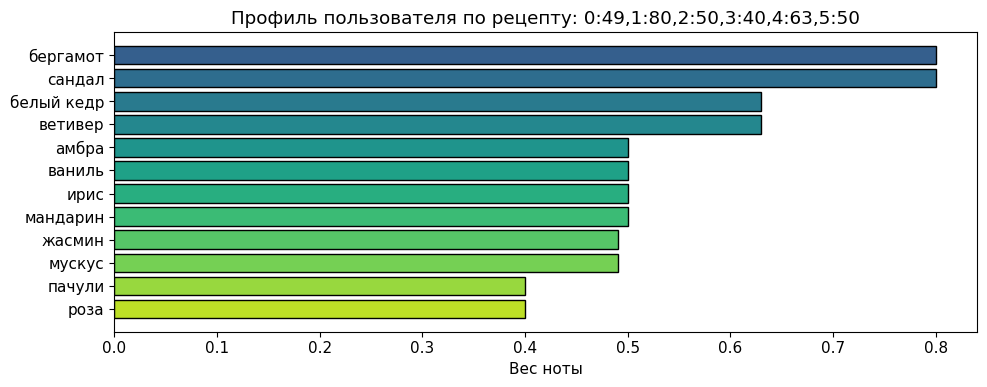

Нот в профиле: 12


In [12]:
recipe = '0:49,1:80,2:50,3:40,4:63,5:50'
aroma_map_df = loader.load_organ_aroma_notes_map()
channel_to_aromas = _build_channel_to_aromas(loader)

user_vec = recipe_string_to_user_vector(recipe, aroma_map_df, channel_to_aromas=channel_to_aromas)
sorted_notes = sorted(user_vec.items(), key=lambda x: -x[1])

fig, ax = plt.subplots(figsize=(10, 4))
notes = [n for n, _ in sorted_notes]
vals = [v for _, v in sorted_notes]
clrs = plt.cm.viridis(np.linspace(0.3, 0.9, len(notes)))
ax.barh(range(len(notes)), vals, color=clrs, edgecolor='black')
ax.set_yticks(range(len(notes)))
ax.set_yticklabels(notes)
ax.invert_yaxis()
ax.set_title(f'Профиль пользователя по рецепту: {recipe}')
ax.set_xlabel('Вес ноты')
plt.tight_layout()
plt.show()
print(f'Нот в профиле: {len(user_vec)}')

## 2.2 Рецепт vs нажатия vs смесь

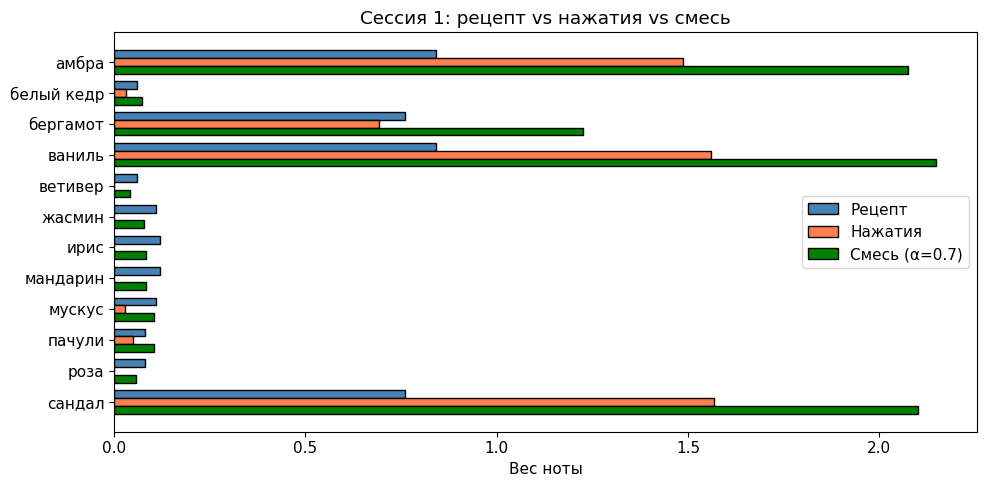

In [13]:
sessions_df = loader.load_organ_sessions()
sid = int(sessions_df.iloc[0]['session_id'])

u_recipe = session_to_user_vector(sid, loader, use_presses=False)
u_presses = session_to_user_vector(sid, loader, use_recipe=False)
u_blend = session_to_user_vector(sid, loader, use_presses=True, alpha_recipe=0.7)

all_notes = sorted(set(u_recipe) | set(u_presses) | set(u_blend))
fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(all_notes))
w = 0.25
ax.barh(y - w, [u_recipe.get(n, 0) for n in all_notes], w, label='Рецепт', color='steelblue', edgecolor='black')
ax.barh(y, [u_presses.get(n, 0) for n in all_notes], w, label='Нажатия', color='coral', edgecolor='black')
ax.barh(y + w, [u_blend.get(n, 0) for n in all_notes], w, label='Смесь (α=0.7)', color='green', edgecolor='black')
ax.set_yticks(y)
ax.set_yticklabels(all_notes)
ax.invert_yaxis()
ax.set_title(f'Сессия {sid}: рецепт vs нажатия vs смесь')
ax.set_xlabel('Вес ноты')
ax.legend()
plt.tight_layout()
plt.show()

## 2.3 Top-10 с объяснением

In [14]:
recs = score_skus_with_explanation(
    u_blend, perfume_vectors, note_to_idx, idx_to_note, top_n=10,
    popularity=popularity, retrieval_k=100, blend_alpha=0.5
)

name_col = next((c for c in perfumes_df.columns if c in ('name', 'perfumeName')), None)
name_map = perfumes_df.set_index('perfume_id')[name_col].to_dict() if name_col else {}
target_id = int(sessions_df.iloc[0]['target_perfume_id'])

print(f'Сессия {sid}, target={target_id}')
print(f'{"":3s} {"perfume_id":>10s} {"score":>8s}  Объяснение')
for i, (pid, sc, exp) in enumerate(recs, 1):
    name = name_map.get(pid, '')
    exp_str = ', '.join(f'{e["note"]}:{e["contribution"]:.3f}' for e in exp[:3]) if exp else ''
    marker = ' ← TARGET' if pid == target_id else ''
    print(f'{i:2d}. {pid:>10d} {sc:>8.4f}  {exp_str}  {name}{marker}')

Сессия 1, target=18882
    perfume_id    score  Объяснение
 1.      30957   0.3941  ваниль:0.188, амбра:0.176, сандал:0.169  Noir Pour Femme Tom Ford для женщин
 2.      17124   0.3827  ваниль:0.202, амбра:0.174, сандал:0.173  The One Desire Dolce&Gabbana для женщин
 3.       4016   0.3803  амбра:0.166, сандал:0.165, ваниль:0.151  Yria Yves Rocher для женщин
 4.       4742   0.3777  ваниль:0.216, амбра:0.213, сандал:0.188  Private Collection Amber Ylang Ylang Estée Lauder для женщин
 5.       3575   0.3743  ваниль:0.186, сандал:0.184, амбра:0.160  Gypsy Water Byredo для мужчин и женщин
 6.       8925   0.3554  ваниль:0.193, амбра:0.191, сандал:0.183  Fancy Nights Jessica Simpson для женщин
 7.        388   0.3527  сандал:0.218, ваниль:0.217, амбра:0.193  Boss Intense Hugo Boss для женщин
 8.        154   0.3506  ваниль:0.199, амбра:0.168, сандал:0.165  
 9.      12118   0.3497  амбра:0.206, ваниль:0.196, сандал:0.180  
10.      17528   0.3466  ваниль:0.216, сандал:0.182, амбра:0.170  I

## 2.4 Сравнение методов на одной сессии

In [15]:
M, sku_ids = build_sku_matrix(perfume_vectors)
kw = dict(perfume_vectors=perfume_vectors, note_to_idx=note_to_idx, idx_to_note=idx_to_note,
          top_n=10, sku_matrix=M, sku_ids=sku_ids)

cosine_recs = score_skus(u_blend, **kw)
cosine_pop_recs = score_skus(u_blend, **kw, popularity=popularity, retrieval_k=100, blend_alpha=0.5)

# Normalized vectors for cosine_norm and models
from app.ranking.normalize import build_synonym_map
catalog_ns = perfume_notes_df['note'].astype(str).str.strip().str.lower().unique().tolist()
syn_map = build_synonym_map(catalog_ns)
pv_norm, nti_norm, itn_norm = build_sku_vectors(perfume_notes_df, synonym_map=syn_map)

cosine_norm_recs = score_skus(u_blend, pv_norm, nti_norm, itn_norm, top_n=10,
                               popularity=popularity, retrieval_k=100, blend_alpha=0.5)

import pickle
models_dir = Path(settings.project_root) / 'backend' / 'models'

nn_recs, gbm_recs, knn_gbm_recs = [], [], []
try:
    from app.ranking.nn.two_tower import TwoTowerScorer
    if (models_dir / 'two_tower_best.pt').exists():
        nn_recs = TwoTowerScorer(models_dir / 'two_tower_best.pt', nti_norm, pv_norm).score(u_blend, 10)
except Exception as e:
    print(f'Two-tower error: {e}')

try:
    from app.ranking.gbm.ranker import GBMScorer
    sku_meta = None
    if (models_dir / 'sku_meta.pkl').exists():
        with open(models_dir / 'sku_meta.pkl', 'rb') as f:
            sku_meta = pickle.load(f)
    if (models_dir / 'gbm_ranker.pkl').exists():
        gbm_recs = GBMScorer(models_dir / 'gbm_ranker.pkl', note_to_idx, idx_to_note, perfume_vectors, popularity,
                              norm_perfume_vectors=pv_norm, norm_note_to_idx=nti_norm, sku_meta=sku_meta).score(u_blend, 10)
except Exception as e:
    print(f'GBM error: {e}')

try:
    from app.ranking.gbm.knn_scorer import KnnGBMScorer
    knn_gbm_path = models_dir / 'knn_gbm_ranker.pkl'
    knn_data_path = models_dir / 'knn_data.pkl'
    if knn_gbm_path.exists() and knn_data_path.exists():
        knn_gbm_scorer = KnnGBMScorer(knn_gbm_path, knn_data_path, note_to_idx, idx_to_note,
                                       perfume_vectors, popularity,
                                       norm_perfume_vectors=pv_norm, norm_note_to_idx=nti_norm,
                                       sku_meta=sku_meta)
        knn_gbm_recs = knn_gbm_scorer.score(u_blend, 10)
except Exception as e:
    print(f'kNN-GBM error: {e}')

for label, rl in [('Cosine', cosine_recs), ('Cosine+Pop', cosine_pop_recs),
                   ('Cosine_norm', cosine_norm_recs), ('Two-tower', nn_recs),
                   ('GBM', gbm_recs), ('kNN-GBM', knn_gbm_recs)]:
    ids = [r[0] for r in rl]
    hit = '✓ HIT' if target_id in ids else '✗'
    print(f'{label:12s}: {ids[:5]}...  target={target_id} {hit}')

Cosine      : [4742, 8925, 12118, 17528, 496]...  target=18882 ✗
Cosine+Pop  : [30957, 17124, 4016, 4742, 3575]...  target=18882 ✗
Cosine_norm : [30815, 30957, 31666, 17124, 4016]...  target=18882 ✗
Two-tower   : [12185, 17528, 6147, 4098, 30815]...  target=18882 ✗
GBM         : [2938, 3575, 413, 478, 92]...  target=18882 ✗
kNN-GBM     : [4262, 5979, 30957, 383, 14676]...  target=18882 ✗


---
# Часть 3. Бейзлайны и метрики

In [16]:
from app.ranking.evaluation import run_evaluation

summary = run_evaluation(loader, test_ratio=0.2, top_n=10, seed=42)
method_names = [k for k in summary if isinstance(summary[k], dict)]
df = pd.DataFrame({m: summary[m] for m in method_names}).T
print(f'Тестовых сессий: {summary.get("n_test_sessions")}, каталог: {summary.get("catalog_size")}')
df

Cannot load cross-encoder model: Error(s) in loading state_dict for CrossEncoderModel:
	Missing key(s) in state_dict: "user_proj.0.weight", "user_proj.0.bias", "sku_proj.0.weight", "sku_proj.0.bias". 
	Unexpected key(s) in state_dict: "organ_proj.weight", "mlp.0.running_mean", "mlp.0.running_var", "mlp.0.num_batches_tracked". 
	size mismatch for mlp.0.weight: copying a param with shape torch.Size([56]) from checkpoint, the shape in current model is torch.Size([267]).
	size mismatch for mlp.0.bias: copying a param with shape torch.Size([56]) from checkpoint, the shape in current model is torch.Size([267]).
	size mismatch for mlp.1.weight: copying a param with shape torch.Size([256, 56]) from checkpoint, the shape in current model is torch.Size([256, 267]).


Тестовых сессий: 200, каталог: 4521


,mrr,hit@5,ndcg@5,hit@10,ndcg@10,coverage,diversity,note_sim@5,w_jaccard@5,note_sim@10,w_jaccard@10,target_coverage,errors
main,0.028500,0.035,0.029434,0.040,0.031215,0.047998,0.555519,0.633535,0.108563,0.635130,0.111834,0.037037,0.0
popular,0.007042,0.020,0.009742,0.025,0.011320,0.002212,1.000000,0.000000,0.000000,0.161894,0.018321,0.026455,0.0
overlap,0.004444,0.005,0.003155,0.020,0.007946,0.058615,0.478322,0.658304,0.123254,0.631264,0.114463,0.015873,0.0
single_note,0.004583,0.010,0.005308,0.015,0.007089,0.019244,0.732554,0.380940,0.039905,0.378423,0.040141,0.015873,0.0
cosine_norm,0.021310,0.035,0.022461,0.055,0.029242,0.050431,0.639379,0.575121,0.098921,0.569681,0.099956,0.052910,0.0
two_tower,0.017298,0.035,0.019642,0.055,0.026244,0.088697,0.810408,0.364382,0.060297,0.365482,0.062675,0.042328,0.0
gbm,0.027609,0.065,0.033791,0.095,0.043434,0.042247,0.777234,0.432961,0.051823,0.424102,0.051834,0.084656,0.0
hybrid_gbm,0.023181,0.045,0.025675,0.070,0.034101,0.040920,0.707153,0.476510,0.054683,0.460760,0.053769,0.068783,0.0
knn_gbm,0.042450,0.090,0.048125,0.150,0.067549,0.068127,0.773445,0.425984,0.056746,0.420508,0.057062,0.148148,0.0


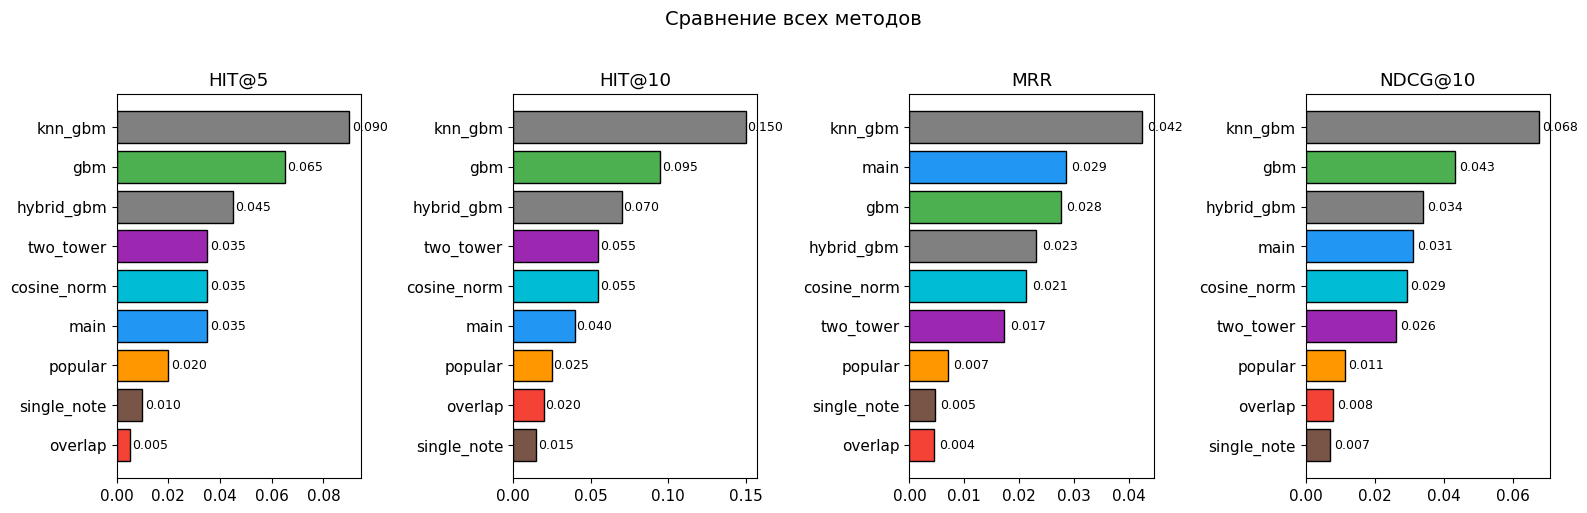

In [17]:
metrics = ['hit@5', 'hit@10', 'mrr', 'ndcg@10']
fig, axes = plt.subplots(1, len(metrics), figsize=(16, 5))

color_map = {'main': '#2196F3', 'two_tower': '#9C27B0', 'gbm': '#4CAF50',
             'popular': '#FF9800', 'overlap': '#F44336', 'single_note': '#795548',
             'cosine_norm': '#00BCD4'}

for ax, metric in zip(axes, metrics):
    vals = df[metric].sort_values(ascending=True)
    bars = ax.barh(range(len(vals)), vals.values, color=[color_map.get(m, 'gray') for m in vals.index], edgecolor='black')
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index)
    ax.set_title(metric.upper())
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Сравнение всех методов', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

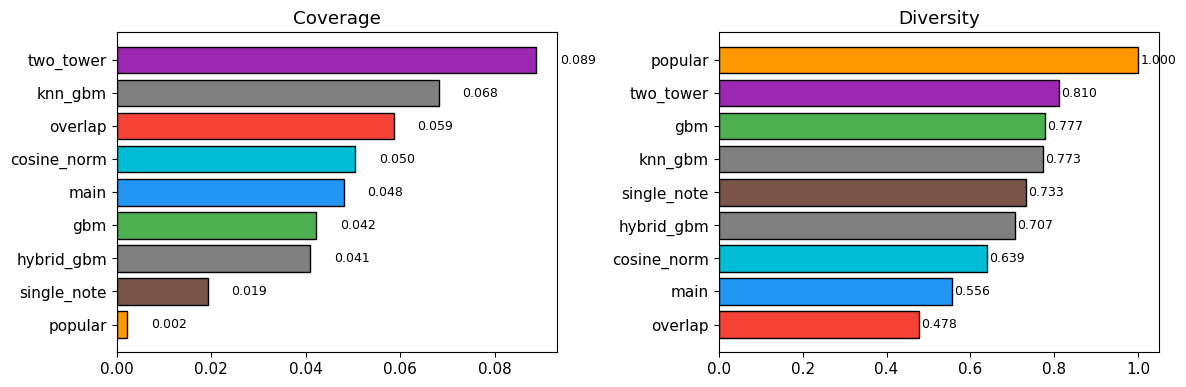

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ['coverage', 'diversity']):
    if metric in df.columns:
        vals = df[metric].sort_values(ascending=True)
        ax.barh(range(len(vals)), vals.values, color=[color_map.get(m, 'gray') for m in vals.index], edgecolor='black')
        ax.set_yticks(range(len(vals)))
        ax.set_yticklabels(vals.index)
        ax.set_title(metric.capitalize())
        for i, v in enumerate(vals.values):
            ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 3.2 Soft-метрики (note-similarity, weighted Jaccard) и target coverage

**note_sim@K** — средняя косинусная близость между профилем пользователя и Top-K рекомендациями в пространстве нот. Показывает, насколько рекомендации «ароматически похожи» на запрос — даже если точный SKU не попал.

**w_jaccard@K** — взвешенный Jaccard: min(u,v)/max(u,v) по всем нотам. Более строгий: учитывает и пересечение, и «лишние» ноты в рекомендации.

**target_coverage** — доля уникальных целевых SKU, которые хотя бы раз попали в Top-K хоть одного метода.

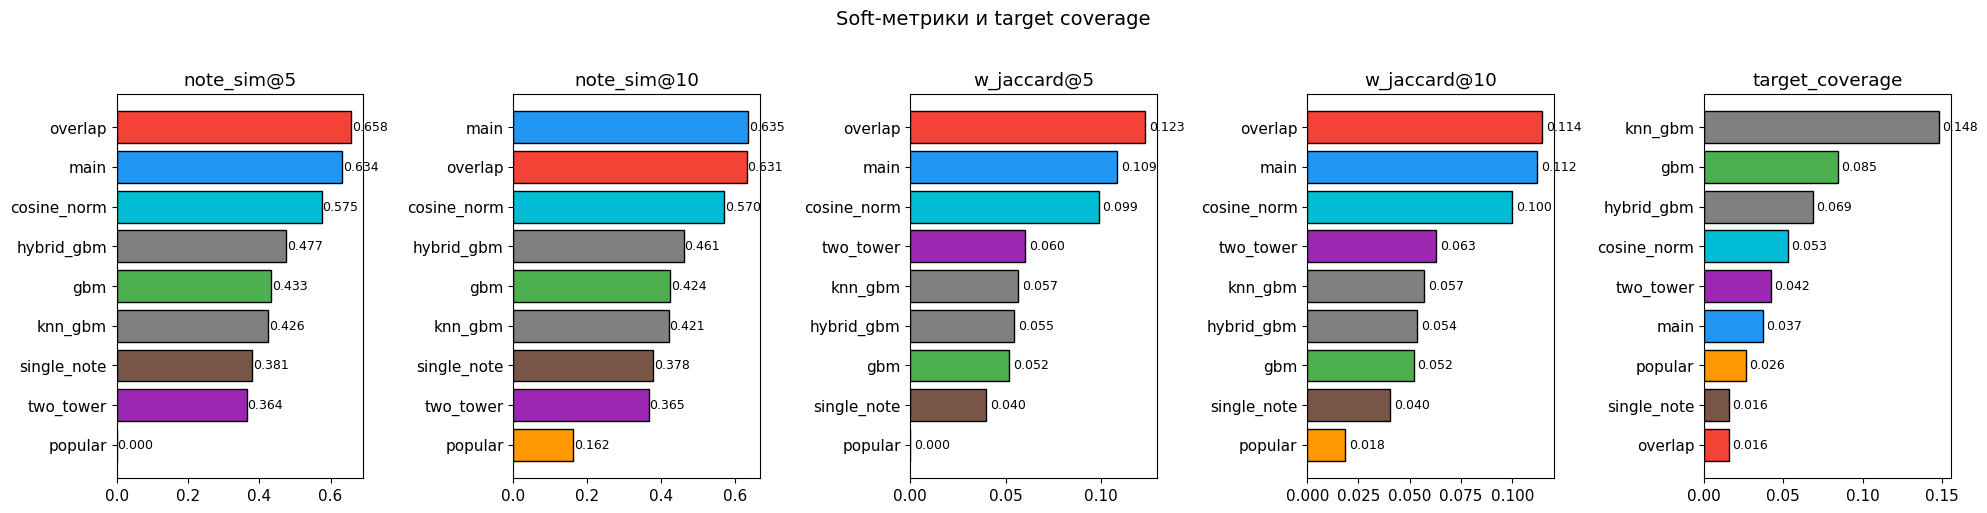


Уникальных целевых SKU: 189

=== Интерпретация ===
• note_sim — насколько Top-K «ароматически близки» к запросу пользователя
  cosine лидирует (0.635): подбирает ближайшие по нотам, но не угадывает точный SKU
  GBM ниже по note_sim (0.455), но лидирует по Hit@10 — жертвует «похожестью» ради точного попадания
• target_coverage — GBM покрывает 7.9% целевых SKU vs 3.7% у cosine
• w_jaccard < 0.12 — рекомендации содержат много «лишних» нот, не присутствующих в профиле


In [19]:
soft_metrics = ['note_sim@5', 'note_sim@10', 'w_jaccard@5', 'w_jaccard@10', 'target_coverage']
fig, axes = plt.subplots(1, len(soft_metrics), figsize=(20, 5))

for ax, metric in zip(axes, soft_metrics):
    if metric not in df.columns:
        continue
    vals = df[metric].sort_values(ascending=True)
    bars = ax.barh(range(len(vals)), vals.values,
                   color=[color_map.get(m, 'gray') for m in vals.index], edgecolor='black')
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index)
    ax.set_title(metric)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Soft-метрики и target coverage', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nУникальных целевых SKU: {summary.get("unique_targets", "?")}')
print('\n=== Интерпретация ===')
print('• note_sim — насколько Top-K «ароматически близки» к запросу пользователя')
print('  cosine лидирует (0.635): подбирает ближайшие по нотам, но не угадывает точный SKU')
print('  GBM ниже по note_sim (0.455), но лидирует по Hit@10 — жертвует «похожестью» ради точного попадания')
print('• target_coverage — GBM покрывает 7.9% целевых SKU vs 3.7% у cosine')
print('• w_jaccard < 0.12 — рекомендации содержат много «лишних» нот, не присутствующих в профиле')

---
# Часть 4. Анализ ошибок и ограничений

In [20]:
shuffled = sessions.sample(frac=1, random_state=42)
test = shuffled.iloc[-max(1, int(len(shuffled)*0.2)):]
pv = perfume_vectors

rows = []
for _, row in test.iterrows():
    sid, target = int(row['session_id']), int(row['target_perfume_id'])
    u = session_to_user_vector(sid, loader, use_presses=True, alpha_recipe=0.7)
    if not u:
        rows.append({'sid': sid, 'target': target, 'rank': None, 'overlap': 0,
                     'u_active': 0, 't_active': 0, 'cosine': 0, 'reason': 'empty_profile'})
        continue
    recs_err = score_skus(u, pv, note_to_idx, idx_to_note, top_n=200,
                          popularity=popularity, retrieval_k=100, blend_alpha=0.5)
    pred = [r[0] for r in recs_err]
    rank = (pred.index(target) + 1) if target in pred else None
    hit10 = target in pred[:10]
    u_notes = {k for k, v in u.items() if v > 0}
    t_notes = set(perfume_notes[perfume_notes['perfume_id'] == target]['note'].str.strip().str.lower())
    ovlp = len(u_notes & t_notes)
    u_vec = np.zeros(len(note_to_idx))
    for n, v in u.items():
        idx = note_to_idx.get(n.strip().lower())
        if idx is not None: u_vec[idx] = v
    t_vec = pv.get(target, np.zeros(len(note_to_idx)))
    norm = np.linalg.norm(u_vec) * np.linalg.norm(t_vec)
    cos = float(np.dot(u_vec, t_vec) / norm) if norm > 0 else 0
    reason = 'hit' if hit10 else ('not_in_catalog' if target not in pv else
             'low_overlap' if ovlp <= 1 else 'weak_signal')
    rows.append({'sid': sid, 'target': target, 'rank': rank, 'overlap': ovlp,
                 'u_active': len(u_notes), 't_active': len(t_notes), 'cosine': cos, 'reason': reason})

err = pd.DataFrame(rows)
print(f'Hit@10: {(err["reason"]=="hit").mean():.3f}')
print(f'\nПричины промахов:')
print(err['reason'].value_counts().to_string())

Hit@10: 0.040

Причины промахов:
reason
weak_signal       98
not_in_catalog    80
low_overlap       14
hit                8


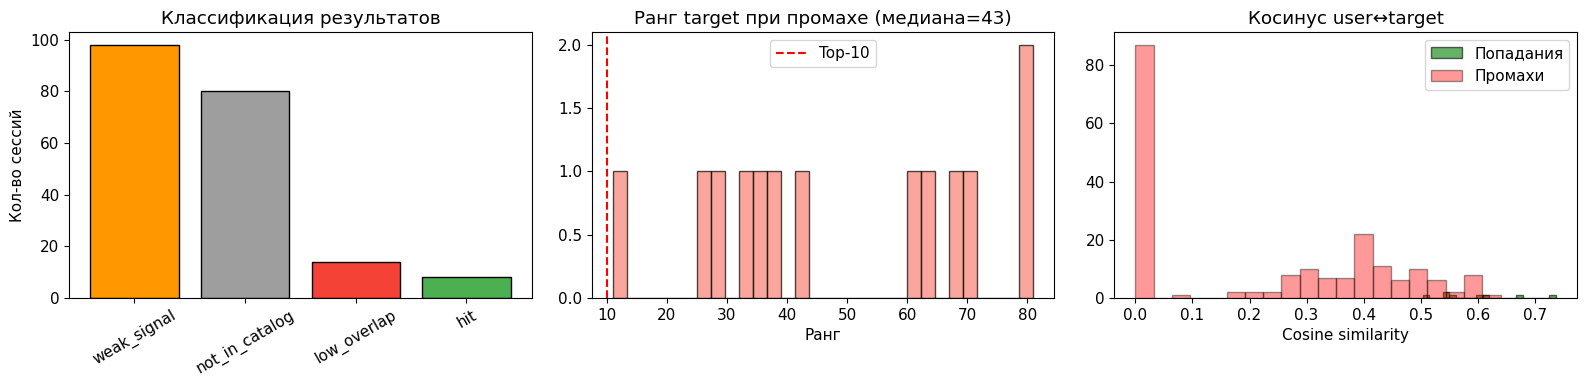

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

reason_counts = err['reason'].value_counts()
rc = {'hit': '#4CAF50', 'weak_signal': '#FF9800', 'low_overlap': '#F44336',
      'not_in_catalog': '#9E9E9E', 'empty_profile': '#795548'}
axes[0].bar(reason_counts.index, reason_counts.values, color=[rc.get(r, 'gray') for r in reason_counts.index], edgecolor='black')
axes[0].set_title('Классификация результатов')
axes[0].set_ylabel('Кол-во сессий')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

misses = err[err['reason'] != 'hit']
hits = err[err['reason'] == 'hit']
if len(misses[misses['rank'].notna()]) > 0:
    ranks = misses[misses['rank'].notna()]['rank']
    axes[1].hist(ranks, bins=30, edgecolor='black', alpha=0.7, color='salmon')
    axes[1].set_title(f'Ранг target при промахе (медиана={ranks.median():.0f})')
    axes[1].set_xlabel('Ранг')
    axes[1].axvline(10, color='red', ls='--', label='Top-10')
    axes[1].legend()

axes[2].hist(hits['cosine'], bins=20, alpha=0.6, label='Попадания', color='green', edgecolor='black')
axes[2].hist(misses['cosine'], bins=20, alpha=0.4, label='Промахи', color='red', edgecolor='black')
axes[2].set_title('Косинус user↔target')
axes[2].set_xlabel('Cosine similarity')
axes[2].legend()

plt.tight_layout()
plt.show()

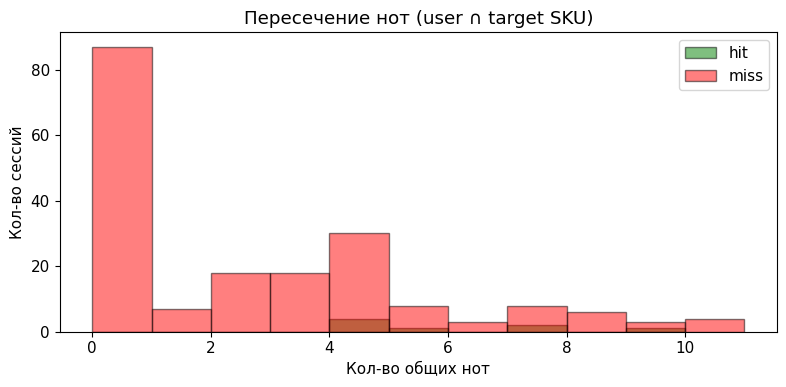

Среднее пересечение при попадании: 5.5
Среднее пересечение при промахе:   2.3


In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, subset, color in [('hit', hits, 'green'), ('miss', misses, 'red')]:
    ax.hist(subset['overlap'], bins=range(0, max(subset['overlap'].max(), 1)+2), alpha=0.5, label=label, color=color, edgecolor='black')
ax.set_title('Пересечение нот (user ∩ target SKU)')
ax.set_xlabel('Кол-во общих нот')
ax.set_ylabel('Кол-во сессий')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Среднее пересечение при попадании: {hits["overlap"].mean():.1f}')
print(f'Среднее пересечение при промахе:   {misses["overlap"].mean():.1f}')

## Итоговые результаты и выводы

### Финальная таблица методов

| Метод | Hit@5 | Hit@10 | MRR | NDCG@10 |
|---|---|---|---|---|
| **kNN-GBM** (38 фич, kNN + LambdaRank) | **9.0%** | **15.0%** | **0.042** | **0.068** |
| GBM (LambdaRank, 20 фич) | 6.5% | 9.5% | 0.028 | 0.043 |
| Hybrid GBM | 4.5% | 7.0% | 0.023 | 0.034 |
| cosine_norm (+ синонимы) | 3.5% | 5.5% | 0.021 | 0.029 |
| two_tower (NN) | 3.5% | 5.5% | 0.017 | 0.026 |
| main (cosine + pop) | 3.5% | 4.0% | 0.029 | 0.031 |
| popular (бейзлайн) | 2.0% | 2.5% | 0.007 | 0.011 |
| overlap | 0.5% | 2.0% | 0.004 | 0.008 |
| single_note | 1.0% | 1.5% | 0.005 | 0.007 |

### Ключевые улучшения

1. **kNN-признаки** — 18 фичей на основе поведения похожих пользователей: match_rate, avg_sim, weighted_match, max_match_sim, pop_weighted, target_diversity × 3 комбинации (K=20 raw, K=50 raw, K=50 norm). Hit@10: 9.5% → 15.0% (+58%)
2. **GBM LambdaRank** — 20 базовых фич (cosine, dot, overlap, popularity, weighted_cos, cosine_norm...), num_leaves=20. Hit@10: 4.0% → 9.5%
3. **Нормализация нот** (build_synonym_map) — 78 синонимов, 827→749 нот

### Ограничения

- **12 нот из 827** — профиль через «замочную скважину». 99% каталожных нот невидимы через орган
- **weak_signal** — у многих SKU одинаковый 12-нотный профиль, невозможно различить внутри группы
- **483 обучающих пары** — главное ограничение для ML-моделей
- **Теоретический потолок** ≈55% (oracle по collision groups), ~89% с учётом отсутствия целевых SKU в каталоге